# 04 - Custom Dataset Training Pipeline

This notebook prepares the final custom cropped-plate dataset, builds metadata, trains CNN recogniser experiments, and evaluates the best checkpoints.

It uses the final seven-character current-style crop folder: `data/raw/plate_crops_LLNNLLL_2`.

The experiments are intentionally short: each training run uses `5` epochs so the notebook is practical to rerun while comparing image sizes and light augmentation.

## Navigation

1. Setup and paths
2. Metadata creation for the final dataset
3. Reusable transforms, datasets, loaders, and training helpers
4. Data-loader sanity checks
5. Experiment matrix
6. Train clean and light-augmentation models
7. Compare experiments
8. Evaluate the selected checkpoint
9. Error analysis
10. Optional stress evaluation
11. Optional final checkpoint promotion

## 1. Setup and Paths

In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path
from typing import Any

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader


def find_anpr_project_root() -> Path:
    """Find the uk_plate_recognition project root from common notebook launch locations."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        cwd / "uk_plate_recognition",
        cwd.parent / "uk_plate_recognition",
    ]

    for candidate in candidates:
        if (candidate / "src" / "anpr").exists() and (candidate / "data").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find uk_plate_recognition project root. "
        "Run this notebook from the repository root, uk_plate_recognition/, or uk_plate_recognition/notebooks/."
    )


PROJECT_ROOT = find_anpr_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from anpr.data.dataset import PlateDataset
from anpr.data.metadata import build_metadata_csv
from anpr.data.transforms import get_eval_transforms, get_stress_test_transforms
from anpr.evaluation.metrics import format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import evaluate_one_epoch, train_one_epoch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

FINAL_DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "plate_crops_LLNNLLL_2"
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates_custom_final.csv"
INVALID_METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "invalid_plates_custom_final.csv"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "custom_data_cnn_v2"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "custom_dataset_training"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
NUM_EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.1
POOLED_WIDTH = 10
PLATE_LENGTH = 7
NUM_WORKERS = 0

print("Project root:", PROJECT_ROOT)
print("Dataset:", FINAL_DATASET_DIR)
print("Metadata:", METADATA_CSV)
print("Device:", DEVICE)

Project root: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition
Dataset: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_LLNNLLL_2
Metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_final.csv
Device: cpu


## 2. Metadata Creation for the Final Dataset

In [7]:
if not FINAL_DATASET_DIR.exists():
    raise FileNotFoundError(f"Final dataset folder not found: {FINAL_DATASET_DIR}")

metadata_df = build_metadata_csv(
    image_dir=FINAL_DATASET_DIR,
    output_csv=METADATA_CSV,
    invalid_csv=INVALID_METADATA_CSV,
    project_root=PROJECT_ROOT,
    source_name="plate_crops_LLNNLLL_2",
    allow_embedded_plate=True,
    random_state=RANDOM_STATE,
)

print("Saved metadata:", METADATA_CSV)
print("Rows:", len(metadata_df))
display(metadata_df.head())
display(metadata_df["split"].value_counts().rename_axis("split").reset_index(name="images"))
display(metadata_df["label"].value_counts().describe().to_frame("images_per_label"))

Saved metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_final.csv
Rows: 12221


,image_id,image_path,label,label_length,source,split
0,AC08UHJ,data/raw/plate_crops_LLNNLLL_2/AC08UHJ.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,val
1,AC08UHJ_002,data/raw/plate_crops_LLNNLLL_2/AC08UHJ_002.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,val
2,AC21AJW,data/raw/plate_crops_LLNNLLL_2/AC21AJW.jpg,AC21AJW,7,plate_crops_LLNNLLL_2,train
3,AD08CAO,data/raw/plate_crops_LLNNLLL_2/AD08CAO.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,train
4,AD08CAO_002,data/raw/plate_crops_LLNNLLL_2/AD08CAO_002.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,train


,split,images
0,train,9784
1,test,1231
2,val,1206


,images_per_label
count,11156.000000
mean,1.095464
std,0.388232
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


## 3. Reusable Transforms, Datasets, Loaders, and Training Helpers

In [2]:
def md(text: str) -> None:
    display(Markdown(text))


def get_light_train_transforms(image_height: int, image_width: int) -> A.Compose:
    """
    Light augmentation for already-varied real cropped plates.

    The dataset already contains real blur, compression, lighting, and crop variation,
    so these transforms are deliberately weaker than the baseline notebook augmentation.
    """
    return A.Compose(
        [
            A.Resize(height=image_height, width=image_width),
            A.Affine(
                scale=(0.98, 1.02),
                translate_percent=(-0.01, 0.01),
                rotate=(-1.5, 1.5),
                shear=(-1.0, 1.0),
                p=0.20,
            ),
            A.OneOf(
                [
                    A.MotionBlur(blur_limit=3, p=1.0),
                    A.GaussianBlur(blur_limit=3, p=1.0),
                ],
                p=0.10,
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.08,
                contrast_limit=0.08,
                p=0.20,
            ),
            A.GaussNoise(p=0.08),
            A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ]
    )


def build_datasets(image_height: int, image_width: int, train_augmented: bool = False):
    train_transform = (
        get_light_train_transforms(image_height=image_height, image_width=image_width)
        if train_augmented
        else get_eval_transforms(image_height=image_height, image_width=image_width)
    )
    eval_transform = get_eval_transforms(image_height=image_height, image_width=image_width)

    def dataset_for(split: str, transform):
        return PlateDataset(
            metadata=METADATA_CSV,
            project_root=PROJECT_ROOT,
            split=split,
            transform=transform,
            grayscale=True,
        )

    return (
        dataset_for("train", train_transform),
        dataset_for("val", eval_transform),
        dataset_for("test", eval_transform),
    )


def make_loaders(train_ds, val_ds, test_ds, batch_size: int = BATCH_SIZE):
    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
    }
    return (
        DataLoader(train_ds, shuffle=True, **loader_kwargs),
        DataLoader(val_ds, shuffle=False, **loader_kwargs),
        DataLoader(test_ds, shuffle=False, **loader_kwargs),
    )


def build_model() -> PlateCNN:
    return PlateCNN(in_channels=1, dropout=DROPOUT, pooled_width=POOLED_WIDTH).to(DEVICE)


def history_row(epoch: int, train_result, val_result) -> dict[str, Any]:
    metrics = val_result.metrics
    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": metrics.full_plate_accuracy,
        "val_regex_valid_rate": metrics.regex_valid_rate,
        "val_average_confidence": metrics.average_confidence,
    }
    for position, accuracy in enumerate(metrics.per_position_accuracy):
        row[f"val_position_{position}_acc"] = accuracy
    return row


def train_experiment(
    experiment_name: str,
    image_height: int,
    image_width: int,
    train_augmented: bool,
    num_epochs: int = NUM_EPOCHS,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    train_ds, val_ds, test_ds = build_datasets(
        image_height=image_height,
        image_width=image_width,
        train_augmented=train_augmented,
    )
    train_loader, val_loader, test_loader = make_loaders(train_ds, val_ds, test_ds)

    model = build_model()
    loss_fn = PlateMultiHeadLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    checkpoint_path = CHECKPOINT_DIR / f"{experiment_name}_best.pt"
    best_val_accuracy = 0.0
    history = []

    print(f"\n=== {experiment_name} ===")
    print("Image size:", (image_height, image_width))
    print("Light augmentation:", train_augmented)
    print("Trainable parameters:", count_trainable_parameters(model))

    for epoch in range(1, num_epochs + 1):
        train_result = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE, show_progress=True)
        val_result = evaluate_one_epoch(model, val_loader, loss_fn, DEVICE, show_progress=True)
        row = history_row(epoch, train_result, val_result)
        history.append(row)

        print(
            f"Epoch {epoch:02d} | train_loss={train_result.loss:.4f} | "
            f"val_loss={val_result.loss:.4f} | "
            f"val_full_plate_acc={row['val_full_plate_accuracy']:.4f} | "
            f"confidence={row['val_average_confidence']:.4f}"
        )

        if row["val_full_plate_accuracy"] > best_val_accuracy:
            best_val_accuracy = row["val_full_plate_accuracy"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch,
                    "best_val_accuracy": best_val_accuracy,
                    "history": history,
                    "model_config": {
                        "in_channels": 1,
                        "dropout": DROPOUT,
                        "pooled_width": POOLED_WIDTH,
                        "image_height": image_height,
                        "image_width": image_width,
                        "grayscale": True,
                    },
                    "experiment_config": {
                        "experiment_name": experiment_name,
                        "train_augmented": train_augmented,
                        "metadata_csv": str(METADATA_CSV),
                        "dataset_dir": str(FINAL_DATASET_DIR),
                        "num_epochs": num_epochs,
                        "lr": LR,
                        "weight_decay": WEIGHT_DECAY,
                    },
                },
                checkpoint_path,
            )
            print("Saved new best checkpoint:", checkpoint_path)

    history_df = pd.DataFrame(history)
    history_path = OUTPUT_DIR / f"{experiment_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    best_model, checkpoint = load_checkpoint_model(checkpoint_path)
    test_result = evaluate_model(best_model, test_loader, f"{experiment_name} test")

    summary = {
        "experiment": experiment_name,
        "image_height": image_height,
        "image_width": image_width,
        "light_augmentation": train_augmented,
        "checkpoint_path": str(checkpoint_path),
        "best_epoch": checkpoint["epoch"],
        "best_val_accuracy": checkpoint["best_val_accuracy"],
        "test_loss": test_result.loss,
        "test_full_plate_accuracy": test_result.metrics.full_plate_accuracy,
        "test_regex_valid_rate": test_result.metrics.regex_valid_rate,
        "test_average_confidence": test_result.metrics.average_confidence,
    }
    return history_df, summary


def load_checkpoint_model(checkpoint_path: Path) -> tuple[PlateCNN, dict[str, Any]]:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint["model_config"]
    model = PlateCNN(
        in_channels=config["in_channels"],
        dropout=config["dropout"],
        pooled_width=config["pooled_width"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def evaluate_model(model: PlateCNN, loader: DataLoader, label: str):
    result = evaluate_one_epoch(model, loader, PlateMultiHeadLoss(), DEVICE, show_progress=True)
    print(f"{label} loss:", result.loss)
    print(format_plate_metrics(result.metrics))
    return result


def export_predictions(model: PlateCNN, loader: DataLoader, filename: str) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            labels = list(batch["label"])
            image_paths = list(batch["image_path"])
            predictions = decode_model_outputs(model(images))

            for image_path, true_label, prediction in zip(image_paths, labels, predictions):
                predicted_label = prediction.cleaned_prediction
                row = {
                    "image_path": image_path,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct": predicted_label == true_label,
                    "confidence": prediction.overall_confidence,
                    "regex_valid": prediction.is_valid_format,
                }
                for position in range(PLATE_LENGTH):
                    row[f"true_pos_{position}"] = true_label[position]
                    row[f"pred_pos_{position}"] = predicted_label[position]
                    row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                    row[f"pos_{position}_confidence"] = prediction.position_confidences[position]
                rows.append(row)

    predictions_df = pd.DataFrame(rows)
    output_path = OUTPUT_DIR / filename
    predictions_df.to_csv(output_path, index=False)
    print("Saved predictions:", output_path)
    return predictions_df

In [3]:
def denormalise_plate_tensor(image_tensor):
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    return image.clip(0, 1)


def show_batch(dataset, title: str, num_images: int = 16) -> None:
    loader = DataLoader(dataset, batch_size=num_images, shuffle=True, num_workers=0)
    batch = next(iter(loader))
    cols = 4
    rows = (min(num_images, len(batch["label"])) + cols - 1) // cols
    plt.figure(figsize=(14, 3.2 * rows), dpi=90)
    for index in range(min(num_images, len(batch["label"]))):
        plt.subplot(rows, cols, index + 1)
        plt.imshow(denormalise_plate_tensor(batch["image"][index]), cmap="gray")
        plt.title(batch["label"][index])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def resolve_image_path(path_value) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def show_error_images(errors_df: pd.DataFrame, max_images: int = 12) -> None:
    rows = errors_df.head(max_images).reset_index(drop=True)
    if rows.empty:
        print("No images to display.")
        return

    cols = 3
    plot_rows = (len(rows) + cols - 1) // cols
    plt.figure(figsize=(14, 3.6 * plot_rows), dpi=90)
    for index, row in rows.iterrows():
        image_path = resolve_image_path(row["image_path"])
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            print("Could not read image:", image_path)
            continue
        plt.subplot(plot_rows, cols, index + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.4f}"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_full_plate_accuracy"], label="Val full-plate accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} validation accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()


def inspect_errors(predictions_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    errors_df = predictions_df[~predictions_df["correct"]].copy()
    print("Number of errors:", len(errors_df))
    print("Full-plate accuracy:", predictions_df["correct"].mean())
    return errors_df.sort_values("confidence", ascending=False).head(max_rows)


def position_error_summary(predictions_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "position": position,
            "accuracy": predictions_df[f"pos_{position}_correct"].mean(),
            "errors": (~predictions_df[f"pos_{position}_correct"]).sum(),
        }
        for position in range(PLATE_LENGTH)
    )


def character_errors(predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in predictions_df[~predictions_df["correct"]].iterrows():
        for position in range(PLATE_LENGTH):
            true_char = row["true_label"][position]
            pred_char = row["predicted_label"][position]
            if true_char != pred_char:
                rows.append(
                    {
                        "image_path": row["image_path"],
                        "true_label": row["true_label"],
                        "predicted_label": row["predicted_label"],
                        "position": position,
                        "true_char": true_char,
                        "pred_char": pred_char,
                        "plate_confidence": row["confidence"],
                        "position_confidence": row[f"pos_{position}_confidence"],
                    }
                )
    return pd.DataFrame(rows)

## 4. Data-Loader Sanity Checks

In [5]:
clean_train_ds, clean_val_ds, clean_test_ds = build_datasets(48, 160, train_augmented=False)
light_aug_train_ds, _, _ = build_datasets(48, 160, train_augmented=True)

print("Dataset sizes:", len(clean_train_ds), len(clean_val_ds), len(clean_test_ds))
sample = clean_train_ds[0]
print("Sample image shape:", tuple(sample["image"].shape))
print("Sample target shape:", tuple(sample["target"].shape))
print("Sample label:", sample["label"])

train_loader, val_loader, test_loader = make_loaders(clean_train_ds, clean_val_ds, clean_test_ds)
batch = next(iter(train_loader))
print("Batch image shape:", tuple(batch["image"].shape))
print("Batch target shape:", tuple(batch["target"].shape))

Dataset sizes: 9814 1211 1197
Sample image shape: (1, 48, 160)
Sample target shape: (7,)
Sample label: AC21AJW
Batch image shape: (64, 1, 48, 160)
Batch target shape: (64, 7)


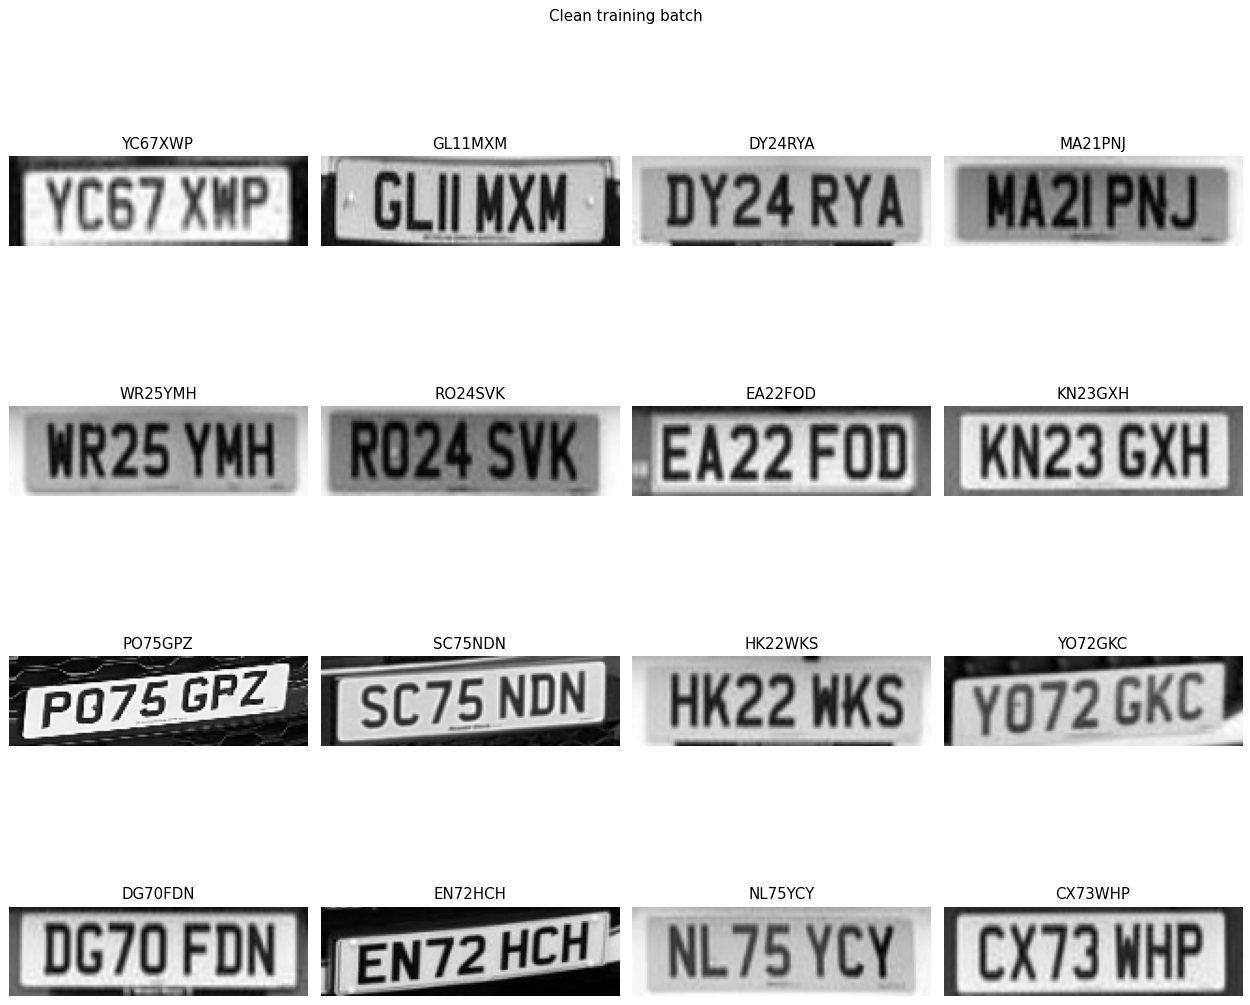

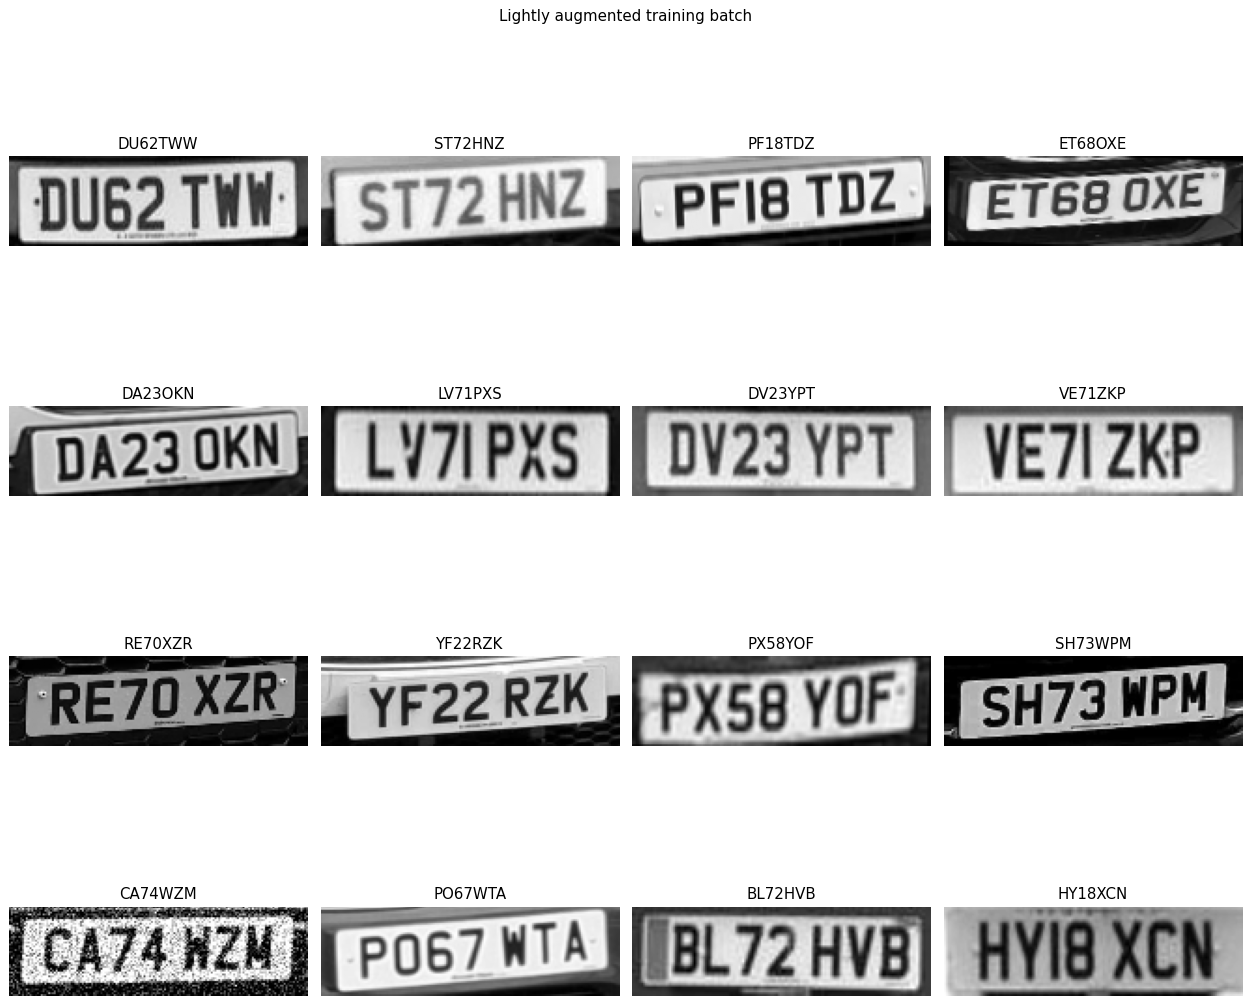

In [6]:
show_batch(clean_train_ds, "Clean training batch", num_images=16)
show_batch(light_aug_train_ds, "Lightly augmented training batch", num_images=16)

## 5. Experiment Matrix

In [7]:
EXPERIMENTS = [
    {
        "experiment_name": "custom_clean_48x160",
        "image_height": 48,
        "image_width": 160,
        "train_augmented": False,
    },
    {
        "experiment_name": "custom_light_aug_48x160",
        "image_height": 48,
        "image_width": 160,
        "train_augmented": True,
    },
    {
        "experiment_name": "custom_clean_36x124",
        "image_height": 36,
        "image_width": 124,
        "train_augmented": False,
    },
    {
        "experiment_name": "custom_light_aug_36x124",
        "image_height": 36,
        "image_width": 124,
        "train_augmented": True,
    },
]

experiments_df = pd.DataFrame(EXPERIMENTS)
experiments_df["epochs"] = NUM_EPOCHS
display(experiments_df)

,experiment_name,image_height,image_width,train_augmented,epochs
0,custom_clean_48x160,48,160,False,5
1,custom_light_aug_48x160,48,160,True,5
2,custom_clean_36x124,36,124,False,5
3,custom_light_aug_36x124,36,124,True,5


## 6. Train Clean and Light-Augmentation Models


=== custom_clean_48x160 ===
Image size: (48, 160)
Light augmentation: False
Trainable parameters: 772470


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.7757 | val_loss=0.7990 | val_full_plate_acc=0.2164 | confidence=0.6199
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_48x160_best.pt


Training:   0%|          | 0/154 [00:00<?, ?it/s]

...

Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0690 | val_loss=0.1026 | val_full_plate_acc=0.8993 | confidence=0.9569
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_48x160_best.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

custom_clean_48x160 test loss: 0.09596810900079478
Samples: 1197
Full-plate accuracy: 0.8972
Regex-valid rate: 1.0000
Average confidence: 0.9572
Per-position accuracy:
  Position 0: 0.9900
  Position 1: 0.9708
  Position 2: 0.9850
  Position 3: 0.9791
  Position 4: 0.9657
  Position 5: 0.9549
  Position 6: 0.9741


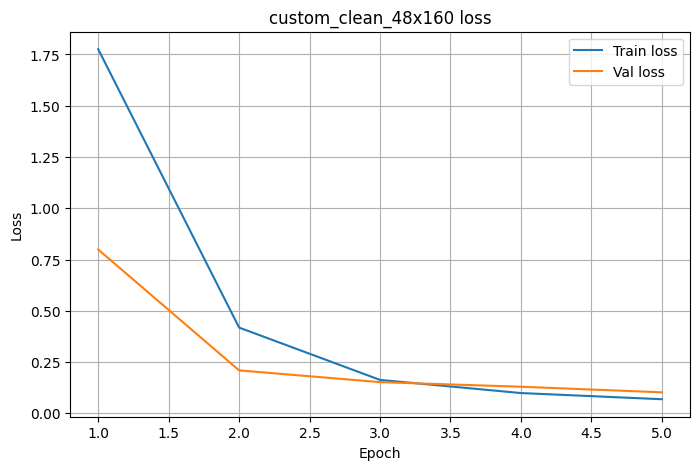

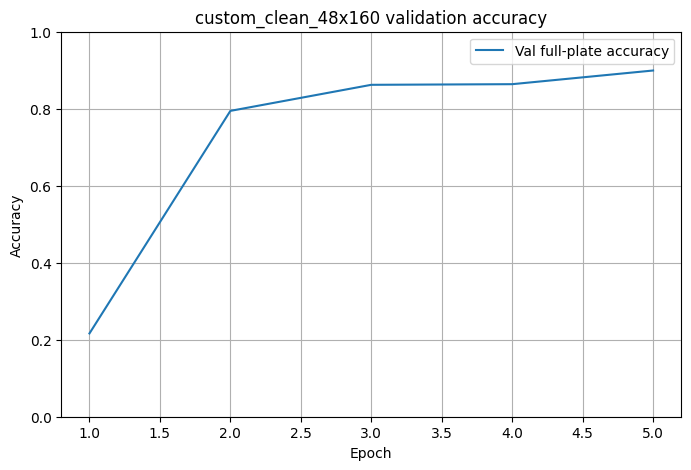


=== custom_light_aug_48x160 ===
Image size: (48, 160)
Light augmentation: True
Trainable parameters: 772470


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | train_loss=2.0025 | val_loss=1.0187 | val_full_plate_acc=0.0801 | confidence=0.5538
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_light_aug_48x160_best.pt


Training:   0%|          | 0/154 [00:00<?, ?it/s]

...

Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.1441 | val_loss=0.1148 | val_full_plate_acc=0.8918 | confidence=0.9498
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_light_aug_48x160_best.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

custom_light_aug_48x160 test loss: 0.10970011858912239
Samples: 1197
Full-plate accuracy: 0.8931
Regex-valid rate: 1.0000
Average confidence: 0.9518
Per-position accuracy:
  Position 0: 0.9883
  Position 1: 0.9674
  Position 2: 0.9825
  Position 3: 0.9783
  Position 4: 0.9825
  Position 5: 0.9532
  Position 6: 0.9716


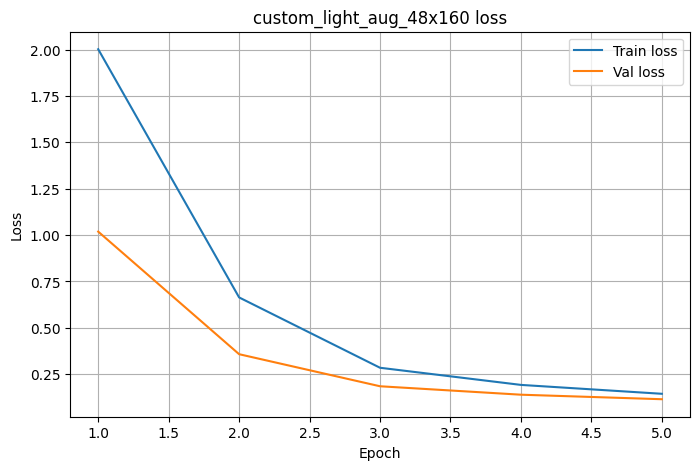

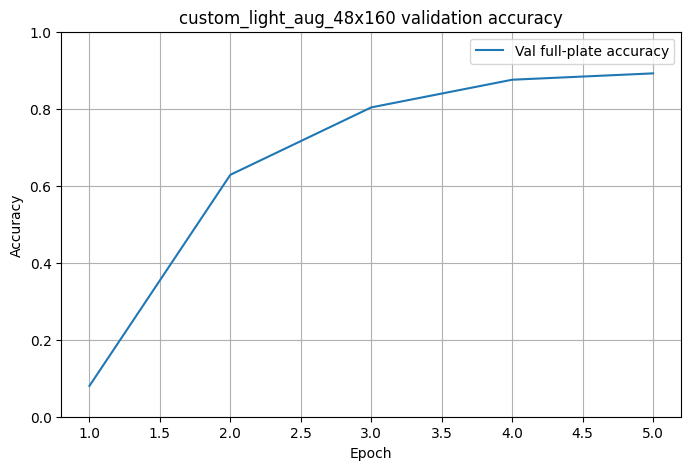


=== custom_clean_36x124 ===
Image size: (36, 124)
Light augmentation: False
Trainable parameters: 772470


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.7100 | val_loss=0.7205 | val_full_plate_acc=0.2898 | confidence=0.6289
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_36x124_best.pt


Training:   0%|          | 0/154 [00:00<?, ?it/s]

...

Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0377 | val_loss=0.0799 | val_full_plate_acc=0.9075 | confidence=0.9712
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_36x124_best.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

custom_clean_36x124 test loss: 0.07701273945315042
Samples: 1197
Full-plate accuracy: 0.9081
Regex-valid rate: 1.0000
Average confidence: 0.9704
Per-position accuracy:
  Position 0: 0.9950
  Position 1: 0.9791
  Position 2: 0.9866
  Position 3: 0.9833
  Position 4: 0.9791
  Position 5: 0.9549
  Position 6: 0.9741


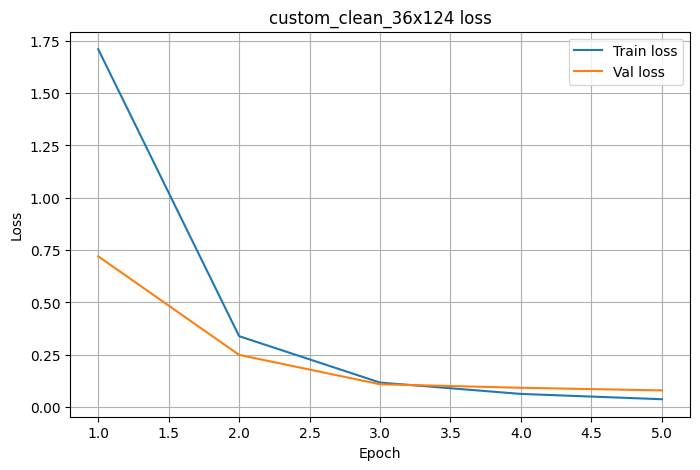

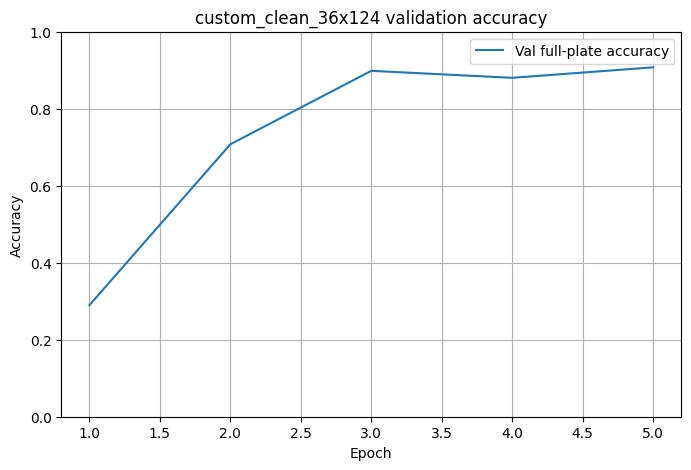


=== custom_light_aug_36x124 ===
Image size: (36, 124)
Light augmentation: True
Trainable parameters: 772470


Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.9058 | val_loss=0.8936 | val_full_plate_acc=0.1478 | confidence=0.5905
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_light_aug_36x124_best.pt


Training:   0%|          | 0/154 [00:00<?, ?it/s]

...

Training:   0%|          | 0/154 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.1288 | val_loss=0.1011 | val_full_plate_acc=0.8827 | confidence=0.9572
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_light_aug_36x124_best.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

custom_light_aug_36x124 test loss: 0.09334922121307107
Samples: 1197
Full-plate accuracy: 0.8989
Regex-valid rate: 1.0000
Average confidence: 0.9561
Per-position accuracy:
  Position 0: 0.9841
  Position 1: 0.9716
  Position 2: 0.9883
  Position 3: 0.9875
  Position 4: 0.9766
  Position 5: 0.9574
  Position 6: 0.9774


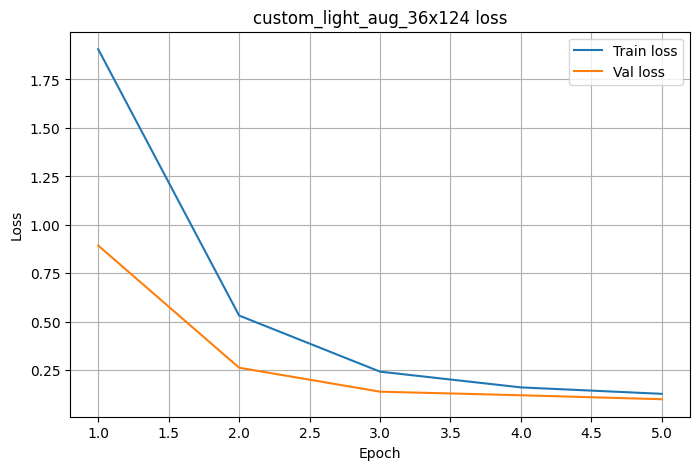

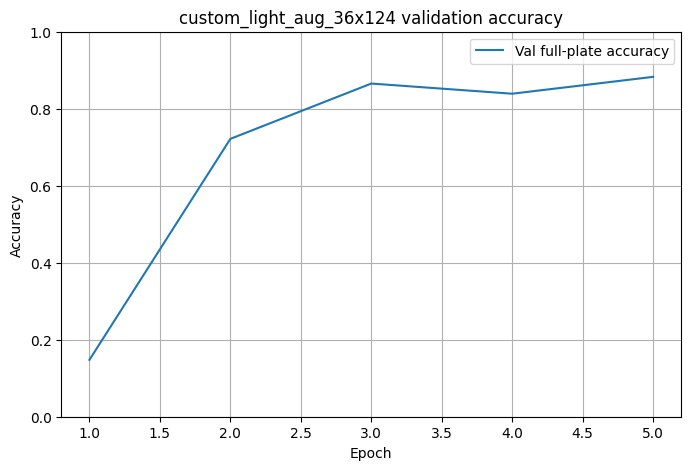

Saved comparison: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\custom_dataset_experiment_comparison.csv


,experiment,image_height,image_width,light_augmentation,checkpoint_path,best_epoch,best_val_accuracy,test_loss,test_full_plate_accuracy,test_regex_valid_rate,test_average_confidence
2,custom_clean_36x124,36,124,False,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.907514,0.077013,0.908104,1.0,0.970424
3,custom_light_aug_36x124,36,124,True,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.882742,0.093349,0.898914,1.0,0.956064
0,custom_clean_48x160,48,160,False,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.899257,0.095968,0.897243,1.0,0.957225
1,custom_light_aug_48x160,48,160,True,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.891825,0.109700,0.893066,1.0,0.951796


In [8]:
histories: dict[str, pd.DataFrame] = {}
experiment_summaries = []

for spec in EXPERIMENTS:
    history_df, summary = train_experiment(**spec, num_epochs=NUM_EPOCHS)
    histories[spec["experiment_name"]] = history_df
    experiment_summaries.append(summary)
    plot_history(history_df, spec["experiment_name"])

comparison_df = pd.DataFrame(experiment_summaries).sort_values(
    ["test_full_plate_accuracy", "best_val_accuracy"],
    ascending=False,
)
comparison_path = OUTPUT_DIR / "custom_dataset_experiment_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved comparison:", comparison_path)
display(comparison_df)

## 7. Compare Experiments

,experiment,image_height,image_width,light_augmentation,checkpoint_path,best_epoch,best_val_accuracy,test_loss,test_full_plate_accuracy,test_regex_valid_rate,test_average_confidence
2,custom_clean_36x124,36,124,False,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.907514,0.077013,0.908104,1.0,0.970424
3,custom_light_aug_36x124,36,124,True,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.882742,0.093349,0.898914,1.0,0.956064
0,custom_clean_48x160,48,160,False,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.899257,0.095968,0.897243,1.0,0.957225
1,custom_light_aug_48x160,48,160,True,C:\Users\kosko\OneDrive\Python\machine_learnin...,5,0.891825,0.109700,0.893066,1.0,0.951796


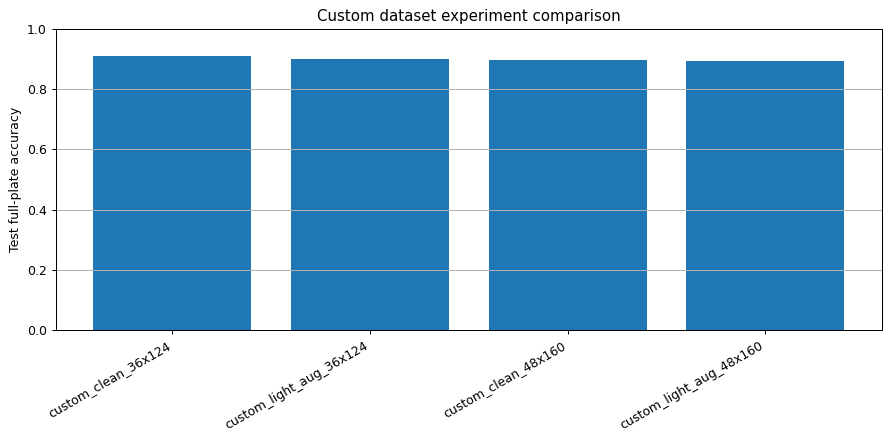

In [9]:
if "comparison_df" not in globals():
    comparison_df = pd.read_csv(OUTPUT_DIR / "custom_dataset_experiment_comparison.csv")

display(comparison_df)

plt.figure(figsize=(10, 5), dpi=90)
plt.bar(comparison_df["experiment"], comparison_df["test_full_plate_accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test full-plate accuracy")
plt.ylim(0, 1)
plt.title("Custom dataset experiment comparison")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## 8. Evaluate the Selected Checkpoint

In [ ]:
BEST_EXPERIMENT_NAME = comparison_df.iloc[0]["experiment"]
BEST_CHECKPOINT_PATH = Path(comparison_df.iloc[0]["checkpoint_path"])

best_model, best_checkpoint = load_checkpoint_model(BEST_CHECKPOINT_PATH)
best_config = best_checkpoint["model_config"]

_, _, selected_test_ds = build_datasets(
    image_height=best_config["image_height"],
    image_width=best_config["image_width"],
    train_augmented=False,
)
selected_test_loader = DataLoader(
    selected_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Best experiment:", BEST_EXPERIMENT_NAME)
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
evaluate_model(best_model, selected_test_loader, f"{BEST_EXPERIMENT_NAME} selected test")
predictions_df = export_predictions(
    best_model,
    selected_test_loader,
    f"{BEST_EXPERIMENT_NAME}_test_predictions.csv",
)
display(predictions_df.head())

Best experiment: custom_clean_36x124
Best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_36x124_best.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

custom_clean_36x124 selected test loss: 0.07701273945315042
Samples: 1197
Full-plate accuracy: 0.9081
Regex-valid rate: 1.0000
Average confidence: 0.9704
Per-position accuracy:
  Position 0: 0.9950
  Position 1: 0.9791
  Position 2: 0.9866
  Position 3: 0.9833
  Position 4: 0.9791
  Position 5: 0.9549
  Position 6: 0.9741
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\custom_clean_36x124_test_predictions.csv


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AD66UTT,AO66UTT,False,0.928875,True,A,A,True,0.996890,...,True,0.963812,T,T,True,0.976214,T,T,True,0.996670
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE23RSO,AE23RSO,True,0.996050,True,A,A,True,0.996322,...,True,0.996425,S,S,True,0.997398,O,O,True,0.997579
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE70UUX,AE70UUX,True,0.985163,True,A,A,True,0.999031,...,True,0.999758,U,U,True,0.900752,X,X,True,0.996979
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE75XFU,AE75XFU,True,0.992468,True,A,A,True,0.997188,...,True,0.999570,F,F,True,0.995167,U,U,True,0.969341
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AF23GUJ,AF23GJJ,False,0.904983,True,A,A,True,0.989839,...,True,0.998095,U,J,False,0.511679,J,J,True,0.999309


## 9. Error Analysis

In [15]:
errors_df = predictions_df[~predictions_df["correct"]].copy()
print("Errors:", len(errors_df))
print("Accuracy:", predictions_df["correct"].mean())

display(inspect_errors(predictions_df, max_rows=30))
display(position_error_summary(predictions_df))

char_errors_df = character_errors(predictions_df)
char_errors_path = OUTPUT_DIR / f"{BEST_EXPERIMENT_NAME}_character_errors.csv"
char_errors_df.to_csv(char_errors_path, index=False)
print("Saved character errors:", char_errors_path)
display(char_errors_df.groupby(["position", "true_char", "pred_char"]).size().reset_index(name="count").sort_values("count", ascending=False).head(30))

Errors: 110
Accuracy: 0.9081035923141186
Number of errors: 110
Full-plate accuracy: 0.9081035923141186


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
649,C:\Users\kosko\OneDrive\Python\machine_learnin...,LV25BDF,LV25BOF,False,0.980333,True,L,L,True,0.999860,...,True,0.900393,D,O,False,0.972015,F,F,True,0.999786
445,C:\Users\kosko\OneDrive\Python\machine_learnin...,GY72WTV,GY72WTY,False,0.977980,True,G,G,True,0.978287,...,True,0.903221,T,T,True,0.985839,V,Y,False,0.981820
607,C:\Users\kosko\OneDrive\Python\machine_learnin...,LM23YVS,LM23YSS,False,0.977233,True,L,L,True,0.999825,...,True,0.999808,V,S,False,0.970788,S,S,True,0.925933
407,C:\Users\kosko\OneDrive\Python\machine_learnin...,GF18UJL,GF18ULL,False,0.968796,True,G,G,True,0.986996,...,True,0.997512,J,L,False,0.909238,L,L,True,0.895324
1142,C:\Users\kosko\OneDrive\Python\machine_learnin...,YO72FXV,YO72FXY,False,0.967881,True,Y,Y,True,0.999711,...,True,0.950062,X,X,True,0.974595,V,Y,False,0.884767
114,C:\Users\kosko\OneDrive\Python\machine_learnin...,CA18POH,CA18OOH,False,0.963099,True,C,C,True,0.999205,...,False,0.773789,O,O,True,0.997239,H,H,True,0.989105
967,C:\Users\kosko\OneDrive\Python\machine_learnin...,SY68LTO,YY68LTO,False,0.962309,True,S,Y,False,0.948965,...,True,0.967189,T,T,True,0.989970,O,O,True,0.996544
1037,C:\Users\kosko\OneDrive\Python\machine_learnin...,WN26WUL,VN26WUL,False,0.959600,True,W,V,False,0.972050,...,True,0.950441,U,U,True,0.988435,L,L,True,0.990999
843,C:\Users\kosko\OneDrive\Python\machine_learnin...,RJ23YFP,RJ23YYP,False,0.956443,True,R,R,True,0.881954,...,True,0.983610,F,Y,False,0.890118,P,P,True,0.946973
571,C:\Users\kosko\OneDrive\Python\machine_learnin...,LF22UDB,LF22UUB,False,0.954722,True,L,L,True,0.999754,...,True,0.998112,D,U,False,0.688394,B,B,True,0.997926


,position,accuracy,errors
0,0,0.994987,6
1,1,0.979114,25
2,2,0.986633,16
3,3,0.983292,20
4,4,0.979114,25
5,5,0.954887,54
6,6,0.974102,31


Saved character errors: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\custom_clean_36x124_character_errors.csv


,position,true_char,pred_char,count
136,6,V,Y,6
77,5,D,O,4
39,3,1,7,3
122,6,D,O,3
63,4,M,N,3
102,5,U,O,3
106,5,V,Y,3
33,2,6,1,3
126,6,M,W,3
10,1,G,E,2


Could not read image: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_LLNNLLL_2\WN26WUL.jpg


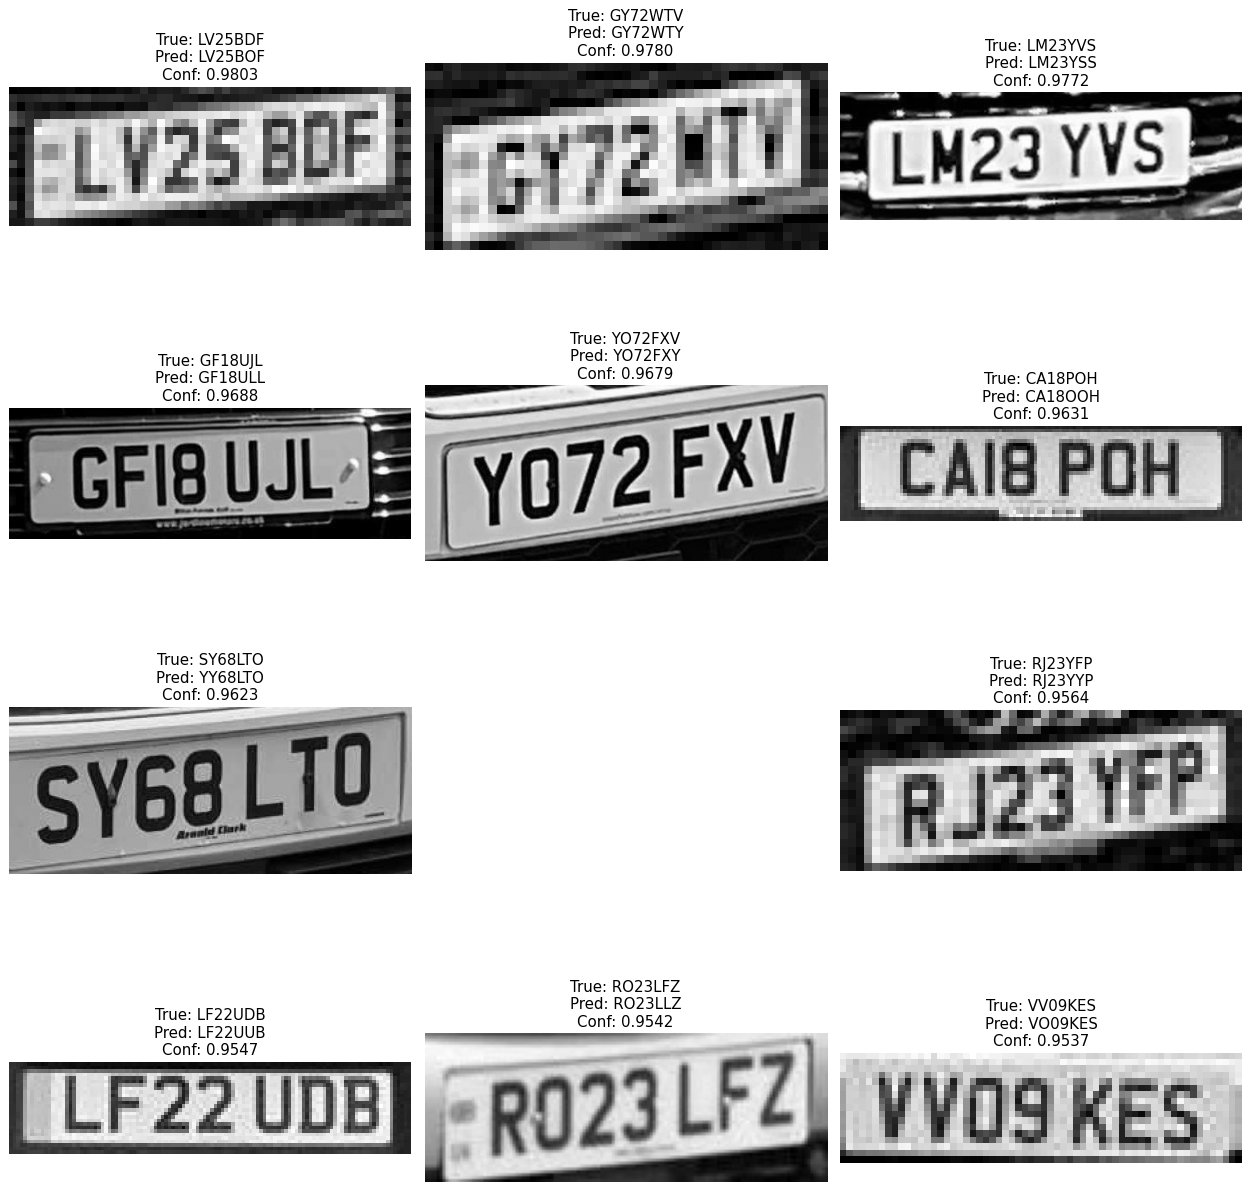

,image_path,true_label,predicted_label,confidence
1011,C:\Users\kosko\OneDrive\Python\machine_learnin...,WF16UTN,WF16UTN,0.671772
855,C:\Users\kosko\OneDrive\Python\machine_learnin...,RO25VKB,RO25VKB,0.729143
135,C:\Users\kosko\OneDrive\Python\machine_learnin...,CK15GBE,CK15GBE,0.835122
293,C:\Users\kosko\OneDrive\Python\machine_learnin...,EN16YXM,EN16YXM,0.836764
713,C:\Users\kosko\OneDrive\Python\machine_learnin...,MT24UYC,MT24UYC,0.842328
1008,C:\Users\kosko\OneDrive\Python\machine_learnin...,WD23SFJ,WD23SFJ,0.849192
1042,C:\Users\kosko\OneDrive\Python\machine_learnin...,WO67GVZ,WO67GVZ,0.860302
996,C:\Users\kosko\OneDrive\Python\machine_learnin...,WA20TGK,WA20TGK,0.866816
856,C:\Users\kosko\OneDrive\Python\machine_learnin...,RO25VKB,RO25VKB,0.870037
272,C:\Users\kosko\OneDrive\Python\machine_learnin...,EA23XXL,EA23XXL,0.879079


In [20]:
show_error_images(errors_df.sort_values("confidence", ascending=False), max_images=12)

low_conf_correct_df = (
    predictions_df[predictions_df["correct"]]
    .sort_values("confidence", ascending=True)
    .head(20)
)
display(low_conf_correct_df[["image_path", "true_label", "predicted_label", "confidence"]])

## 10. Optional Stress Evaluation

In [8]:
RUN_STRESS_EVAL = True
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "custom_clean_36x124_best.pt"
BEST_EXPERIMENT_NAME = "custom_clean_36x124"

best_model, best_checkpoint = load_checkpoint_model(BEST_CHECKPOINT_PATH)
best_config = best_checkpoint["model_config"]

def build_stress_loader(image_height: int, image_width: int) -> DataLoader:
    stress_ds = PlateDataset(
        metadata=METADATA_CSV,
        project_root=PROJECT_ROOT,
        split="test",
        transform=get_stress_test_transforms(image_height=image_height, image_width=image_width),
        grayscale=True,
    )
    return DataLoader(
        stress_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


if RUN_STRESS_EVAL:
    stress_loader = build_stress_loader(best_config["image_height"], best_config["image_width"])
    stress_result = evaluate_model(best_model, stress_loader, f"{BEST_EXPERIMENT_NAME} stress")
    stress_summary_df = pd.DataFrame(
        [
            {
                "experiment": BEST_EXPERIMENT_NAME,
                "stress_loss": stress_result.loss,
                "stress_full_plate_accuracy": stress_result.metrics.full_plate_accuracy,
                "stress_regex_valid_rate": stress_result.metrics.regex_valid_rate,
                "stress_average_confidence": stress_result.metrics.average_confidence,
            }
        ]
    )
    stress_summary_path = OUTPUT_DIR / f"{BEST_EXPERIMENT_NAME}_stress_summary.csv"
    stress_summary_df.to_csv(stress_summary_path, index=False)
    display(stress_summary_df)
    print("Saved stress summary:", stress_summary_path)
else:
    print("Stress evaluation skipped. Set RUN_STRESS_EVAL = True to run it.")

C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:129: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:134: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

custom_clean_36x124 stress loss: 1.4208436268408253
Samples: 1231
Full-plate accuracy: 0.6409
Regex-valid rate: 1.0000
Average confidence: 0.8680
Per-position accuracy:
  Position 0: 0.7441
  Position 1: 0.7449
  Position 2: 0.8050
  Position 3: 0.7660
  Position 4: 0.7319
  Position 5: 0.7360
  Position 6: 0.7311


,experiment,stress_loss,stress_full_plate_accuracy,stress_regex_valid_rate,stress_average_confidence
0,custom_clean_36x124,1.420844,0.640942,1.0,0.86804


Saved stress summary: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\custom_clean_36x124_stress_summary.csv


## 11. Optional Final Checkpoint Promotion

In [9]:
PROMOTE_SELECTED_CHECKPOINT = False
FINAL_CHECKPOINT_PATH = CHECKPOINT_DIR / "plate_cnn_final.pt"

if PROMOTE_SELECTED_CHECKPOINT:
    import shutil

    shutil.copy2(BEST_CHECKPOINT_PATH, FINAL_CHECKPOINT_PATH)
    print("Promoted selected checkpoint to:", FINAL_CHECKPOINT_PATH)
else:
    print("Promotion skipped.")
    print("Selected checkpoint:", BEST_CHECKPOINT_PATH)
    print("Final checkpoint target:", FINAL_CHECKPOINT_PATH)

Promotion skipped.
Selected checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\custom_clean_36x124_best.pt
Final checkpoint target: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\plate_cnn_final.pt
